In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tqdm

from ase import Atoms, units
from ase.io import read, write, Trajectory
from ase import units
from mace.calculators import MACECalculator
from ase.data import chemical_symbols

from tensorpotential.calculator import TPCalculator
from tensorpotential.calculator.foundation_models import grace_fm

/home/johannes.karwounopoulos/miniconda3/envs/grace-off/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


2025-10-02 11:09:09.597746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759403349.613667 1761447 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759403349.618992 1761447 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759403349.635051 1761447 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759403349.635068 1761447 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759403349.635070 1761447 computation_placer.cc:177] computation placer alr

In [2]:
# data = h5py.File('../data/TNet500-SPICE.hdf5', 'r')
data = h5py.File('../data/Biaryl-SPICE.hdf5', 'r')

In [ ]:
diff_mace_large = []
diff_mace_medium = []
diff_mace_small = []
diff_grace_1layer_small = []
diff_grace_1layer_medium = []

calc_mae_large = MACECalculator(model_paths="../models/MACE-OFF23_large.model", device="cuda")
calc_mace_medium = MACECalculator(model_paths="../models/MACE-OFF24_medium.model", device="cuda")
calc_mace_small = MACECalculator(model_paths="../models/MACE-OFF23_small.model", device="cuda")

calc_grace_1layer_small = TPCalculator(model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/c_all_small/seed/1/saved_model/")
calc_grace_1layer_medium = TPCalculator(model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/c_all_medium_400_epochs/seed/1/saved_model/")


for key in tqdm.tqdm(data.keys()):     # list(data.keys())[:50]

    Z = data[key]["atomic_numbers"][:]
    symbols = [chemical_symbols[int(z)] for z in Z]
    dft_energies = data[key]['dft total energy'][:] * 27.211386245988
    dft_energies = [e - min(dft_energies) for e in dft_energies]

    energies_mace_large = []
    energies_mace_medium = []
    energies_mace_small = []
    energies_grace_1layer_small = []
    energies_grace_1layer_medium = []


    for i in range(len(data[key]["conformations"])):
        pos = data[key]["conformations"][i][:] * units.Bohr
        mol = Atoms(symbols=symbols, positions=pos)

        mol.calc = calc_mae_large
        e = mol.get_potential_energy()
        energies_mace_large.append(e)

        mol.calc = calc_mace_medium
        e = mol.get_potential_energy()
        energies_mace_medium.append(e)

        mol.calc = calc_mace_small
        e = mol.get_potential_energy()
        energies_mace_small.append(e)

        mol.calc = calc_grace_1layer_small
        e = mol.get_potential_energy()
        energies_grace_1layer_small.append(e)

        mol.calc = calc_grace_1layer_medium
        e = mol.get_potential_energy()
        energies_grace_1layer_medium.append(e)

    energies_mace_large = [e - min(energies_mace_large) for e in energies_mace_large]
    energies_mace_medium = [e - min(energies_mace_medium) for e in energies_mace_medium]
    energies_mace_small = [e - min(energies_mace_small) for e in energies_mace_small]
    energies_grace_1layer_small = [e - min(energies_grace_1layer_small) for e in energies_grace_1layer_small]
    energies_grace_1layer_medium = [e - min(energies_grace_1layer_medium) for e in energies_grace_1layer_medium]

    diff_mace_large.append(np.mean(np.asarray(energies_mace_large)-np.asarray(dft_energies)))
    diff_mace_medium.append(np.mean(np.asarray(energies_mace_medium)-np.asarray(dft_energies)))
    diff_mace_small.append(np.mean(np.asarray(energies_mace_small)-np.asarray(dft_energies)))
    diff_grace_1layer_small.append(np.mean(np.asarray(energies_grace_1layer_small)-np.asarray(dft_energies)))
    diff_grace_1layer_medium.append(np.mean(np.asarray(energies_grace_1layer_medium)-np.asarray(dft_energies)))



/home/johannes.karwounopoulos/miniconda3/envs/grace-off/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/grace-off/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/grace-off/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=m

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


 59%|█████▉    | 52/88 [03:38<02:36,  4.36s/it]

MACE large modell: 0.003
MACE medium modell: 0.006
MACE small modell: 0.008
Mod Grace modell: 0.03
Mod Grace medium modell: 0.009


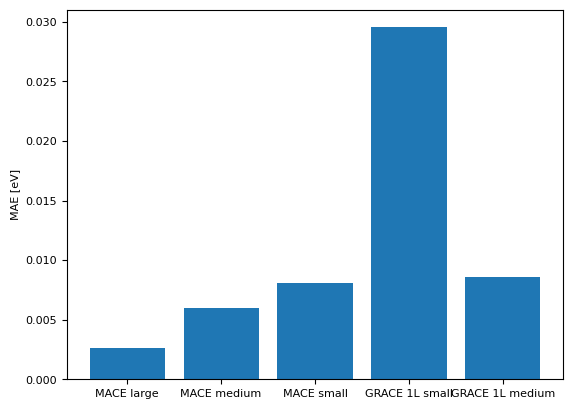

In [5]:


print("MACE large modell:", round(np.mean(np.abs(diff_mace_large)), 3))
print("MACE medium modell:", round(np.mean(np.abs(diff_mace_medium)), 3))
print("MACE small modell:", round(np.mean(np.abs(diff_mace_small)), 3))
print("Mod Grace modell:", round(np.mean(np.abs(diff_grace_1layer_small)), 3))
print("Mod Grace medium modell:", round(np.mean(np.abs(diff_grace_1layer_medium)), 3))


plt.bar(["MACE large", "MACE medium", "MACE small", "GRACE 1L small", "GRACE 1L medium"], [np.mean(np.abs(diff_mace_large)), np.mean(np.abs(diff_mace_medium)), np.mean(np.abs(diff_mace_small)), np.mean(np.abs(diff_grace_1layer_small)), np.mean(np.abs(diff_grace_1layer_medium))])
plt.ylabel("MAE [eV]")
# plt.yscale("log")
plt.show()  

In [ ]:
plt.plot(energies_grace_1layer_small, label='GRACE 1L small', marker='o')
plt.plot(energies_grace_1layer_medium, label='GRACE 1L medium', marker='o')
plt.plot(energies_mace_medium, label='MACE medium', marker='o')
# plt.plot(energies_mace_small, label='MACE small', marker='o')
plt.plot(dft_energies, linestyle='dashed', label='DFT', color='black')

plt.legend()